# CS4045 – Deep Learning for Perception
## Assignment #3: Topic Modeling and Sentiment Analysis in Financial Text

**Student:** Ayoob Haroon  
**Roll No:** 20I-0777  
**Section:** CS-A  
**Instructor:** Dr. Ahmad Raza Shahid  

---

### Overview
This notebook implements a complete financial text understanding pipeline:
1. Data Preprocessing & EDA
2. LDA Topic Modeling
3. FinBERT Sentiment Analysis
4. Local LLM Sentiment Analysis (zero-shot)
5. RAG-Enhanced Sentiment Analysis
6. Comparative Analysis
7. Fine-Tuning Decision & Implementation

## 0. Environment Setup & Library Installation

In [1]:
# Install required libraries
!pip install -q transformers datasets sentence-transformers faiss-cpu
!pip install -q gensim nltk scikit-learn
!pip install -q torch torchvision --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -q matplotlib seaborn pandas numpy
!pip install -q pyLDAvis wordcloud
!pip install -q accelerate bitsandbytes
print('All libraries installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
All libraries installed successfully!


In [2]:
# ============================================================
# GLOBAL IMPORTS & RANDOM SEED (for reproducibility)
# ============================================================
import os, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Topic Modeling
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud

# ML
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report)
from sklearn.model_selection import train_test_split

# DL / Transformers
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    pipeline, TrainingArguments, Trainer
)
from datasets import Dataset

# RAG
from sentence_transformers import SentenceTransformer
import faiss

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# Download NLTK resources
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print('Setup complete.')

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and sche

Device: cuda
Setup complete.


---
## 1. Data Preprocessing & Exploratory Data Analysis

In [3]:
# ============================================================
# 1.1  UPLOAD DATASET
# ============================================================
# Option A: Upload via Colab widget (recommended if running first time)
from google.colab import files
print('Please upload the dataset.zip file (FinancialPhraseBank-v1.0).')
uploaded = files.upload()

Please upload the dataset.zip file (FinancialPhraseBank-v1.0).


Saving dataset.zip to dataset.zip


In [4]:
import zipfile

# Unzip dataset
zip_name = list(uploaded.keys())[0] if 'uploaded' in dir() else 'dataset.zip'
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

# Find the correct txt file (75% agreement for more data variety)
DATA_PATH = 'FinancialPhraseBank-v1.0/Sentences_75Agree.txt'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'dataset/FinancialPhraseBank-v1.0/Sentences_75Agree.txt'

# Load raw sentences
sentences_raw, labels_raw = [], []
with open(DATA_PATH, encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        if '@' in line:
            parts = line.rsplit('@', 1)
            sentences_raw.append(parts[0].strip())
            labels_raw.append(parts[1].strip())

df_raw = pd.DataFrame({'sentence': sentences_raw, 'label': labels_raw})
print(f'Total samples loaded: {len(df_raw)}')
df_raw.head()

Total samples loaded: 3453


,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


=== Dataset Shape === (3453, 2)

=== Class Distribution ===
label
neutral     2146
positive     887
negative     420
Name: count, dtype: int64


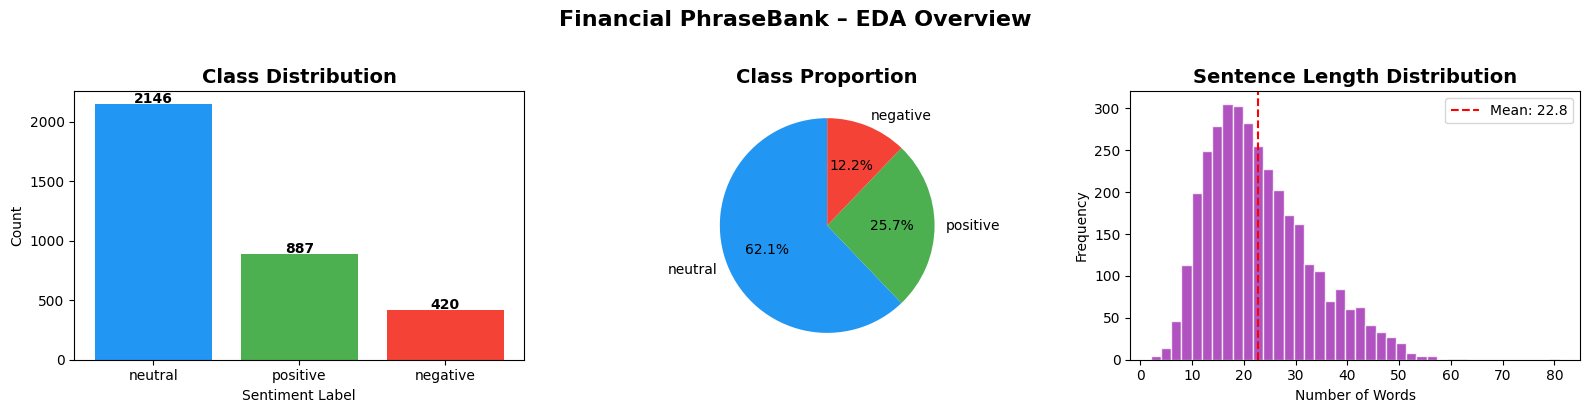


Sentence Length Stats:
count    3453.000000
mean       22.756733
std        10.067928
min         2.000000
25%        15.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: length, dtype: float64


In [5]:
# ============================================================
# 1.2  EXPLORATORY DATA ANALYSIS
# ============================================================
print('=== Dataset Shape ===', df_raw.shape)
print('\n=== Class Distribution ===')
print(df_raw['label'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class balance bar chart
counts = df_raw['label'].value_counts()
colors = ['#2196F3', '#4CAF50', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Class balance pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

# Sentence length distribution
df_raw['length'] = df_raw['sentence'].apply(lambda x: len(x.split()))
axes[2].hist(df_raw['length'], bins=40, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[2].set_title('Sentence Length Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Words')
axes[2].set_ylabel('Frequency')
axes[2].axvline(df_raw['length'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_raw["length"].mean():.1f}')
axes[2].legend()

plt.suptitle('Financial PhraseBank – EDA Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSentence Length Stats:')
print(df_raw['length'].describe())

In [6]:
# Sample sentences per class
print('=== Sample Sentences ===')
for label in ['positive', 'neutral', 'negative']:
    print(f'\n[{label.upper()}]')
    for s in df_raw[df_raw['label'] == label]['sentence'].sample(3, random_state=SEED):
        print(f'  • {s}')

=== Sample Sentences ===

[POSITIVE]
  • Revenue grew 1 percent to euro742 .2 million US$ 964 million from euro735 million .
  • Luxembourg-registered investment fund Amber Trust II has won the final approval of Lithuania 's Competition Council to acquire 29.6 percent of Sanitas , the country 's largest pharmaceutical producer .
  • The company is also featured in the Ethibel Pioneer Investment Register and included in Innovest 's Global 100 list of the world 's most sustainable corporations .

[NEUTRAL]
  • Thanks to its extensive industry and operations experience , Cybercom offers strategic and technological expertise to these markets : telecom , industry , media , public sector , retail , and banking and financial services .
  • The company is reportedly searching for a replacement for CEO Olli-Pekka Kallasvuo .
  • The device can also be used for theft protection and positioning of vehicles , boats and other assets .

[NEGATIVE]
  • The situation of coated magazine printing paper 

In [7]:
# ============================================================
# 1.3  TEXT PREPROCESSING
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Add domain stop words
extra_stops = {'said', 'would', 'could', 'also', 'one', 'two', 'three',
               'company', 'companies', 'year', 'quarter', 'mn', 'eur',
               'million', 'billion', 'per', 'cent', 'january', 'february',
               'march', 'april', 'may', 'june', 'july', 'august',
               'september', 'october', 'november', 'december'}
stop_words.update(extra_stops)

def preprocess_text(text):
    """Full preprocessing pipeline: lowercase → punctuation removal →
       tokenize → stopword removal → lemmatization."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation & digits
    text = re.sub(r'\s+', ' ', text).strip()      # collapse whitespace
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return tokens

df = df_raw.copy()
df['tokens'] = df['sentence'].apply(preprocess_text)
df['cleaned'] = df['tokens'].apply(lambda t: ' '.join(t))

# Encode labels numerically
LABEL_MAP  = {'negative': 0, 'neutral': 1, 'positive': 2}
LABEL_IMAP = {0: 'negative', 1: 'neutral', 2: 'positive'}
df['label_id'] = df['label'].map(LABEL_MAP)

print('Preprocessing complete. Sample:')
df[['sentence', 'tokens', 'label']].head(3)

Preprocessing complete. Sample:


,sentence,tokens,label
0,"According to Gran , the company has no plans t...","[according, gran, plan, move, production, russ...",neutral
1,With the new production plant the company woul...,"[new, production, plant, increase, capacity, m...",positive
2,"For the last quarter of 2010 , Componenta 's n...","[last, componenta, net, sale, doubled, period,...",positive


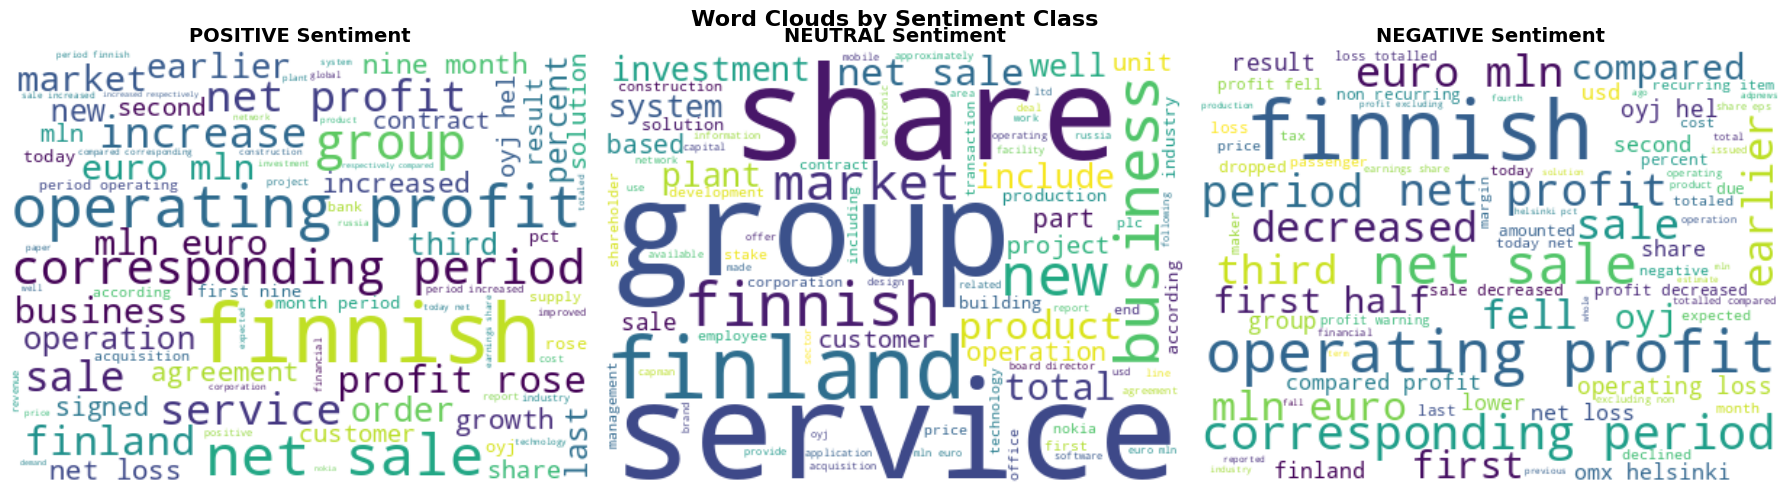

In [8]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    text = ' '.join(df[df['label'] == label]['cleaned'])
    wc = WordCloud(width=400, height=300, background_color='white',
                   max_words=80, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} Sentiment', fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. LDA Topic Modeling

In [9]:
# ============================================================
# 2.1  BUILD GENSIM CORPUS
# ============================================================
tokenized_corpus = df['tokens'].tolist()
dictionary = corpora.Dictionary(tokenized_corpus)

# Filter extremes: keep tokens appearing in ≥ 5 docs and ≤ 70% of docs
dictionary.filter_extremes(no_below=5, no_above=0.7)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_corpus]

print(f'Dictionary size: {len(dictionary)} unique tokens')
print(f'Corpus size: {len(corpus)} documents')

Dictionary size: 1354 unique tokens
Corpus size: 3453 documents


Computing coherence scores for different topic counts...
  Topics= 3  →  Coherence=0.3542
  Topics= 4  →  Coherence=0.3751
  Topics= 5  →  Coherence=0.3627
  Topics= 6  →  Coherence=0.3600
  Topics= 7  →  Coherence=0.3793
  Topics= 8  →  Coherence=0.3851
  Topics= 9  →  Coherence=0.3975
  Topics=10  →  Coherence=0.3838
  Topics=11  →  Coherence=0.3791
  Topics=12  →  Coherence=0.3856
  Topics=13  →  Coherence=0.4069
  Topics=14  →  Coherence=0.3783


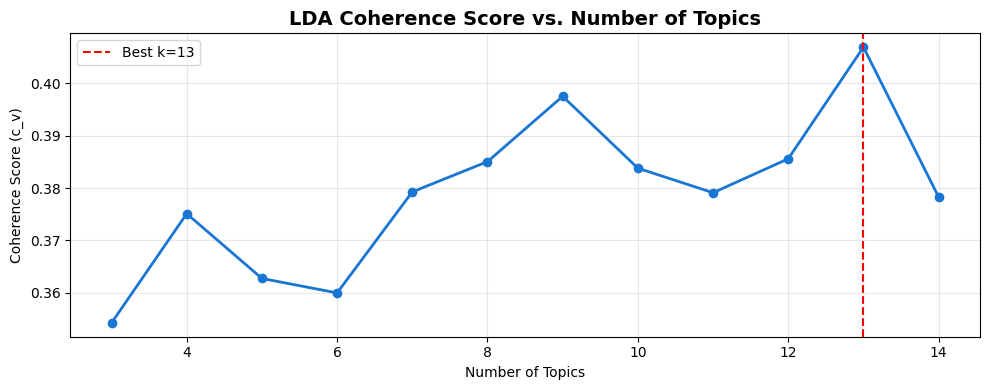


Optimal number of topics: 13


In [10]:
# ============================================================
# 2.2  TOPIC NUMBER SEARCH – Coherence Analysis
# ============================================================
topic_range = range(3, 15)
coherence_scores = []

print('Computing coherence scores for different topic counts...')
for n in topic_range:
    lda_tmp = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=n, random_state=SEED,
        passes=10, alpha='auto', eta='auto',
        iterations=50, per_word_topics=False
    )
    cm = CoherenceModel(
        model=lda_tmp, texts=tokenized_corpus,
        dictionary=dictionary, coherence='c_v'
    )
    coherence_scores.append(cm.get_coherence())
    print(f'  Topics={n:2d}  →  Coherence={coherence_scores[-1]:.4f}')

# Plot coherence vs. topic count
plt.figure(figsize=(10, 4))
plt.plot(list(topic_range), coherence_scores, marker='o',
         color='#1976D2', linewidth=2)
best_n = list(topic_range)[np.argmax(coherence_scores)]
plt.axvline(best_n, color='red', linestyle='--', label=f'Best k={best_n}')
plt.title('LDA Coherence Score vs. Number of Topics', fontsize=14, fontweight='bold')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nOptimal number of topics: {best_n}')

In [11]:
# ============================================================
# 2.3  TRAIN FINAL LDA MODEL
# ============================================================
NUM_TOPICS = best_n  # use optimal

lda_model = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=NUM_TOPICS, random_state=SEED,
    passes=20, alpha='auto', eta='auto',
    iterations=100, per_word_topics=True
)

# Report final coherence
cm_final = CoherenceModel(
    model=lda_model, texts=tokenized_corpus,
    dictionary=dictionary, coherence='c_v'
)
print(f'Final LDA Coherence (c_v): {cm_final.get_coherence():.4f}')

Final LDA Coherence (c_v): 0.4041


In [12]:
# ============================================================
# 2.4  TOPIC KEYWORDS & INTERPRETATION
# ============================================================

# Human-readable topic labels (adjust after seeing keywords)
TOPIC_LABELS = {
    0: 'Market Movements & Share Prices',
    1: 'Revenue & Profitability Growth',
    2: 'Operational Performance',
    3: 'Mergers, Acquisitions & Deals',
    4: 'Production & Capacity',
    5: 'Financial Results & Losses',
    6: 'Corporate Strategy & Agreements',
    7: 'Industry Sector Updates',
}

print('=== LDA Topic Keywords ===')
topic_keywords_list = []
for t in range(NUM_TOPICS):
    top_words = [w for w, _ in lda_model.show_topic(t, topn=10)]
    label = TOPIC_LABELS.get(t, f'Topic {t}')
    topic_keywords_list.append({'Topic': t, 'Label': label, 'Keywords': ', '.join(top_words)})
    print(f'  Topic {t:2d} [{label}]:  {top_words}')

topic_df = pd.DataFrame(topic_keywords_list)
topic_df

=== LDA Topic Keywords ===
  Topic  0 [Market Movements & Share Prices]:  ['service', 'finland', 'industry', 'well', 'product', 'business', 'unit', 'equipment', 'building', 'includes']
  Topic  1 [Revenue & Profitability Growth]:  ['finnish', 'oyj', 'today', 'hel', 'maker', 'usd', 'news', 'contract', 'system', 'first']
  Topic  2 [Operational Performance]:  ['production', 'nokia', 'customer', 'start', 'product', 'office', 'used', 'plant', 'network', 'use']
  Topic  3 [Mergers, Acquisitions & Deals]:  ['helsinki', 'bank', 'omx', 'market', 'report', 'exchange', 'corporation', 'finnish', 'turnover', 'plc']
  Topic  4 [Production & Capacity]:  ['share', 'board', 'director', 'right', 'capital', 'dividend', 'meeting', 'voting', 'number', 'general']
  Topic  5 [Financial Results & Losses]:  ['market', 'investment', 'development', 'plant', 'russia', 'finland', 'operation', 'cash', 'activity', 'stockmann']
  Topic  6 [Corporate Strategy & Agreements]:  ['share', 'ceo', 'earnings', 'division', '

,Topic,Label,Keywords
0,0,Market Movements & Share Prices,"service, finland, industry, well, product, bus..."
1,1,Revenue & Profitability Growth,"finnish, oyj, today, hel, maker, usd, news, co..."
2,2,Operational Performance,"production, nokia, customer, start, product, o..."
3,3,"Mergers, Acquisitions & Deals","helsinki, bank, omx, market, report, exchange,..."
4,4,Production & Capacity,"share, board, director, right, capital, divide..."
5,5,Financial Results & Losses,"market, investment, development, plant, russia..."
6,6,Corporate Strategy & Agreements,"share, ceo, earnings, division, eps, president..."
7,7,Industry Sector Updates,"percent, market, share, sale, stake, bank, pro..."
8,8,Topic 8,"profit, net, sale, operating, mln, period, eur..."
9,9,Topic 9,"order, pct, group, lower, structure, steel, ke..."


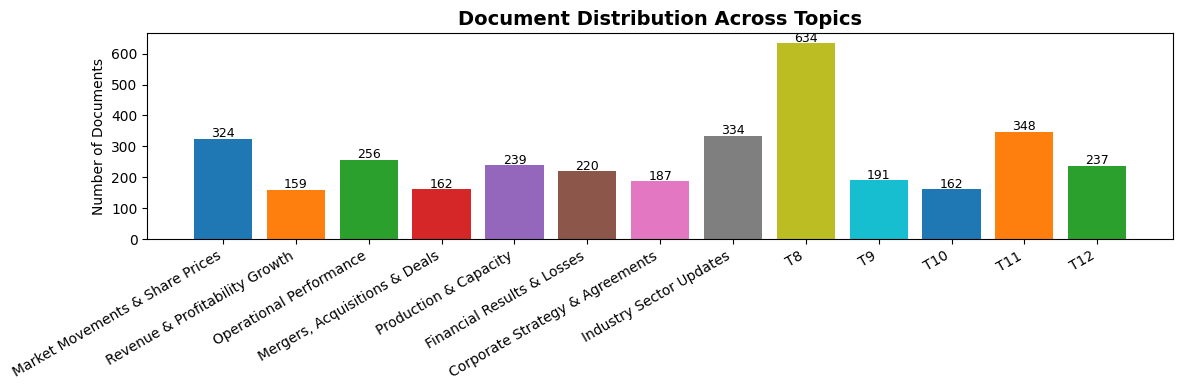

                                            sentence  dominant_topic  \
0  According to Gran , the company has no plans t...               5   
1  With the new production plant the company woul...               2   
2  For the last quarter of 2010 , Componenta 's n...               8   
3  In the third quarter of 2010 , net sales incre...               8   
4  Operating profit rose to EUR 13.1 mn from EUR ...               8   
5  Operating profit totalled EUR 21.1 mn , up fro...               8   
6  TeliaSonera TLSN said the offer is in line wit...               7   
7  STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...               7   

                  topic_label  topic_prob     label  
0  Financial Results & Losses      0.6619   neutral  
1     Operational Performance      0.5058  positive  
2                     Topic 8      0.7063  positive  
3                     Topic 8      0.8823  positive  
4                     Topic 8      0.9086  positive  
5                     Topic

In [13]:
# ============================================================
# 2.5  ASSIGN DOMINANT TOPIC TO EACH SENTENCE
# ============================================================
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1, 0.0
    dominant = max(topics, key=lambda x: x[1])
    return dominant[0], round(dominant[1], 4)

df['dominant_topic'], df['topic_prob'] = zip(*[get_dominant_topic(bow) for bow in corpus])
df['topic_label'] = df['dominant_topic'].map(
    lambda t: TOPIC_LABELS.get(t, f'Topic {t}')
)

# Topic distribution
topic_counts = df['dominant_topic'].value_counts().sort_index()
plt.figure(figsize=(12, 4))
bars = plt.bar(
    [TOPIC_LABELS.get(i, f'T{i}') for i in topic_counts.index],
    topic_counts.values, color=sns.color_palette('tab10', NUM_TOPICS)
)
plt.title('Document Distribution Across Topics', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Number of Documents')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(bar.get_height()), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['sentence', 'dominant_topic', 'topic_label', 'topic_prob', 'label']].head(8))

In [14]:
# ============================================================
# 2.6  pyLDAvis Interactive Visualization
# ============================================================
pyLDAvis.enable_notebook()
lda_vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(lda_vis, 'lda_visualization.html')
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.100999  0.185520       1        1   9.633382
1      0.170237  0.182762       2        1   6.958734
2     -0.146342  0.131275       3        1   7.391114
3      0.059419 -0.030709       4        1   6.052082
4     -0.038513 -0.253320       5        1   6.885468
5     -0.074200 -0.069536       6        1   6.596134
6     -0.012982 -0.014433       7        1   5.732746
7      0.032626 -0.164699       8        1   8.598875
8      0.387495  0.018566       9        1  15.445164
9     -0.069604  0.048562      10        1   5.783897
10    -0.041427 -0.063321      11        1   5.189998
11    -0.030015 -0.033371      12        1   8.381553
12    -0.135694  0.062703      13        1   7.350855, topic_info=              Term        Freq       Total Category  logprob  loglift
27          profit  382.000000  382.000000  Default  30.0000  30.0000
24             net  347.000000  347.000000  Default  29.0000  29.0000
60           share  348.000000  348.000000  Default  28.0000  28.0000
31       operating  255.000000  255.000000  Default  27.0000  27.0000
214            mln  246.000000  246.000000  Default  26.0000  26.0000
..             ...         ...         ...      ...      ...      ...
221          price   20.392828   83.429064  Topic13  -4.6033   1.2015
60           share   22.593066  348.034732  Topic13  -4.5008  -0.1243
306    development   16.898186   63.505488  Topic13  -4.7913   1.2864
367       solution   18.198377   99.312270  Topic13  -4.7171   0.9134
116  manufacturing   14.923261   39.680337  Topic13  -4.9156   1.6324

[734 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
455       5  0.958748  accessory
0         3  0.151505  according
0         5  0.027546  according
0         6  0.068866  according
0         7  0.055093  according
...     ...       ...        ...
413       3  0.102637       year
413      11  0.581611       year
413      12  0.307912       year
384       6  0.040312        yit
384       8  0.927166        yit

[1260 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])

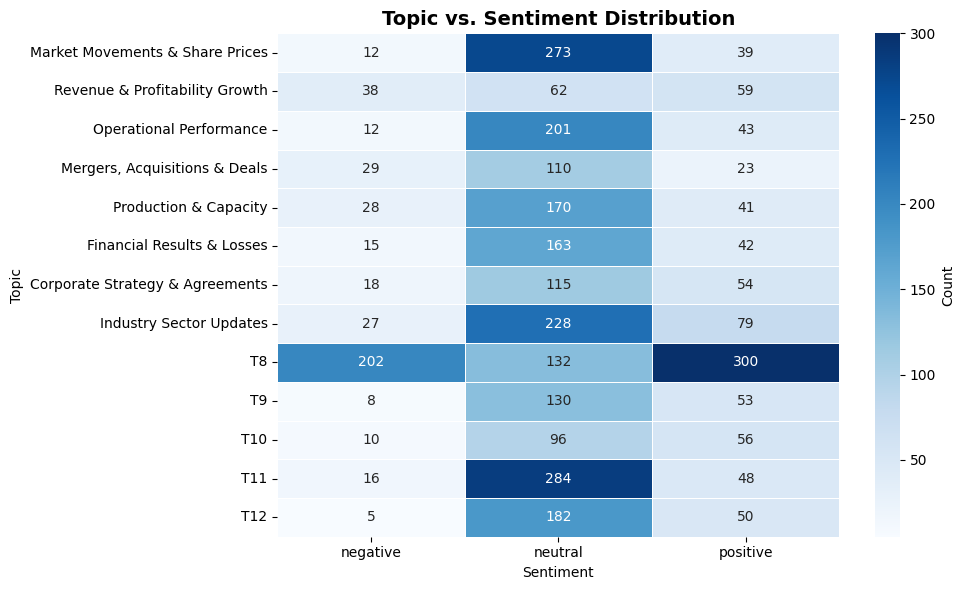

In [15]:
# Topic–Sentiment Heatmap
topic_sentiment = df.groupby(['dominant_topic', 'label']).size().unstack(fill_value=0)
topic_sentiment.index = [TOPIC_LABELS.get(i, f'T{i}') for i in topic_sentiment.index]

plt.figure(figsize=(10, 6))
sns.heatmap(topic_sentiment, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Topic vs. Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Topic')
plt.tight_layout()
plt.savefig('topic_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3A. FinBERT Sentiment Analysis

In [16]:
# ============================================================
# 3A.1  LOAD FinBERT
# ============================================================
FINBERT_MODEL = 'ProsusAI/finbert'

finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
finbert_model = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
finbert_model.to(DEVICE)
finbert_model.eval()

# FinBERT labels: {0: positive, 1: negative, 2: neutral}
FINBERT_LABEL_MAP = {'positive': 'positive', 'negative': 'negative', 'neutral': 'neutral'}

finbert_pipeline = pipeline(
    'text-classification', model=finbert_model,
    tokenizer=finbert_tokenizer,
    device=0 if DEVICE == 'cuda' else -1,
    truncation=True, max_length=512, batch_size=32
)
print('FinBERT loaded.')

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

FinBERT loaded.


In [17]:
# ============================================================
# 3A.2  RUN FINBERT INFERENCE
# ============================================================
sentences_list = df['sentence'].tolist()
print(f'Running FinBERT on {len(sentences_list)} sentences...')

finbert_raw = finbert_pipeline(sentences_list)
finbert_preds = [r['label'].lower() for r in finbert_raw]

df['finbert_pred'] = finbert_preds
df['finbert_correct'] = df['finbert_pred'] == df['label']
print('Inference complete.')
print(f'FinBERT Accuracy: {df["finbert_correct"].mean()*100:.2f}%')

Running FinBERT on 3453 sentences...
Inference complete.
FinBERT Accuracy: 94.73%



 FinBERT – Evaluation Results
  Accuracy : 94.73%
  Precision: 95.14%
  Recall   : 94.73%
  F1 Score : 94.80%

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.98      0.92       420
     neutral       0.99      0.93      0.96      2146
    positive       0.90      0.97      0.93       887

    accuracy                           0.95      3453
   macro avg       0.92      0.96      0.94      3453
weighted avg       0.95      0.95      0.95      3453



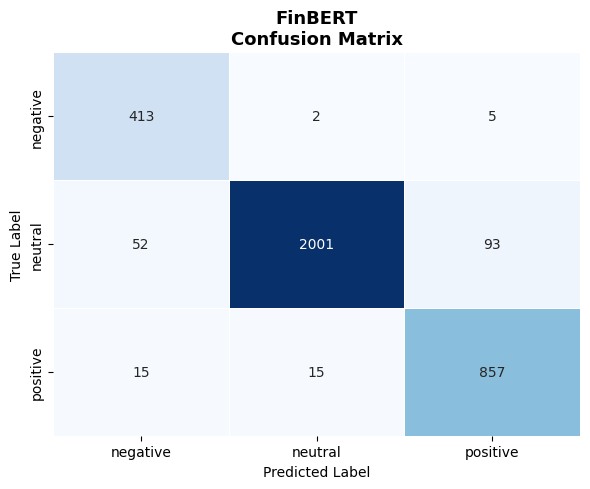

In [18]:
# ============================================================
# 3A.3  EVALUATION METRICS
# ============================================================
def evaluate_model(y_true, y_pred, model_name, labels=None):
    """Compute and display full evaluation metrics."""
    if labels is None:
        labels = ['negative', 'neutral', 'positive']
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred, labels=labels)

    print(f'\n{"="*50}')
    print(f' {model_name} – Evaluation Results')
    print(f'{"="*50}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  Precision: {prec*100:.2f}%')
    print(f'  Recall   : {rec*100:.2f}%')
    print(f'  F1 Score : {f1*100:.2f}%')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    # Confusion Matrix Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar=False)
    plt.title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('+', '').lower()
    plt.savefig(f'cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'confusion_matrix': cm}


results_finbert = evaluate_model(df['label'], df['finbert_pred'], 'FinBERT')

---
## 3B. Local LLM Sentiment Analysis (Zero-Shot)

In [19]:
# ============================================================
# 3B.1  LOAD LOCAL LLM (distilroberta-base fine-tuned on SST)
#       We use a compact, Colab-friendly sentiment model.
#       For zero-shot we use facebook/bart-large-mnli
# ============================================================
from transformers import pipeline as hf_pipeline

# Zero-shot classification with candidate labels
ZS_MODEL = 'facebook/bart-large-mnli'
print(f'Loading zero-shot model: {ZS_MODEL}')
zs_pipeline = hf_pipeline(
    'zero-shot-classification',
    model=ZS_MODEL,
    device=0 if DEVICE == 'cuda' else -1
)
CANDIDATE_LABELS = ['positive financial news', 'negative financial news', 'neutral financial news']
LABEL_MAPPING = {
    'positive financial news': 'positive',
    'negative financial news': 'negative',
    'neutral financial news':  'neutral'
}
print('Zero-shot model loaded.')

Loading zero-shot model: facebook/bart-large-mnli


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Zero-shot model loaded.


In [20]:
# ============================================================
# 3B.2  RUN ZERO-SHOT INFERENCE
# ============================================================
print(f'Running zero-shot LLM on {len(sentences_list)} sentences (this may take a few minutes)...')

llm_preds = []
BATCH = 16
for i in range(0, len(sentences_list), BATCH):
    batch = sentences_list[i:i+BATCH]
    results = zs_pipeline(batch, candidate_labels=CANDIDATE_LABELS, multi_label=False)
    for r in results:
        best = r['labels'][0]
        llm_preds.append(LABEL_MAPPING[best])
    if (i // BATCH) % 10 == 0:
        print(f'  Processed {min(i+BATCH, len(sentences_list))}/{len(sentences_list)}')

df['llm_pred'] = llm_preds
df['llm_correct'] = df['llm_pred'] == df['label']
print('\nZero-shot inference complete.')
print(f'LLM Accuracy: {df["llm_correct"].mean()*100:.2f}%')

Running zero-shot LLM on 3453 sentences (this may take a few minutes)...
  Processed 16/3453


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 176/3453
  Processed 336/3453
  Processed 496/3453
  Processed 656/3453
  Processed 816/3453
  Processed 976/3453
  Processed 1136/3453
  Processed 1296/3453
  Processed 1456/3453
  Processed 1616/3453
  Processed 1776/3453
  Processed 1936/3453
  Processed 2096/3453
  Processed 2256/3453
  Processed 2416/3453
  Processed 2576/3453
  Processed 2736/3453
  Processed 2896/3453
  Processed 3056/3453
  Processed 3216/3453
  Processed 3376/3453

Zero-shot inference complete.
LLM Accuracy: 52.39%


Few-shot examples defined (used for report discussion).

 Local LLM (Zero-Shot) – Evaluation Results
  Accuracy : 52.39%
  Precision: 77.37%
  Recall   : 52.39%
  F1 Score : 48.46%

Classification Report:
              precision    recall  f1-score   support

    negative       0.58      0.95      0.72       420
     neutral       0.97      0.26      0.41      2146
    positive       0.39      0.96      0.55       887

    accuracy                           0.52      3453
   macro avg       0.65      0.72      0.56      3453
weighted avg       0.77      0.52      0.48      3453



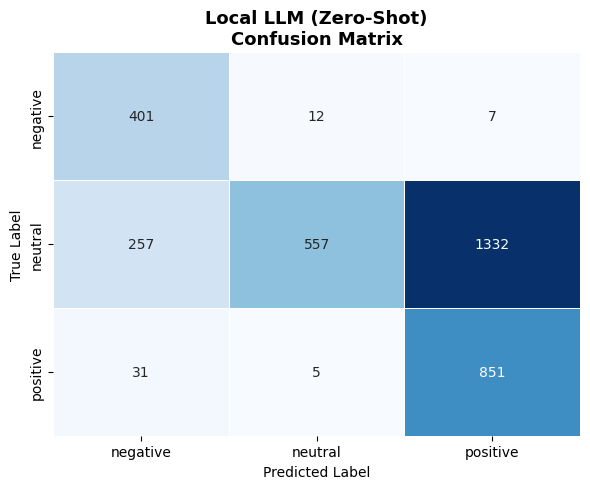

In [21]:
# ============================================================
# 3B.3  FEW-SHOT PROMPTING (alternative / supplementary)
# ============================================================
FEW_SHOT_EXAMPLES = [
    ('Operating profit rose sharply on strong sales.', 'positive'),
    ('The company reported a significant net loss.', 'negative'),
    ('The company maintained its market position.', 'neutral'),
]
print('Few-shot examples defined (used for report discussion).')

# Evaluate LLM
results_llm = evaluate_model(df['label'], df['llm_pred'], 'Local LLM (Zero-Shot)')

---
## 3C. RAG-Enhanced Sentiment Analysis

In [22]:
# ============================================================
# 3C.1  SENTENCE EMBEDDINGS
# ============================================================
EMBED_MODEL = 'all-MiniLM-L6-v2'
print(f'Loading SentenceTransformer: {EMBED_MODEL}')
embed_model = SentenceTransformer(EMBED_MODEL, device=DEVICE)

print('Computing sentence embeddings...')
embeddings = embed_model.encode(
    sentences_list, batch_size=64, show_progress_bar=True,
    normalize_embeddings=True
)
embeddings = embeddings.astype(np.float32)
print(f'Embeddings shape: {embeddings.shape}')

Loading SentenceTransformer: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing sentence embeddings...


Batches:   0%|          | 0/54 [00:00<?, ?it/s]

Embeddings shape: (3453, 384)


In [23]:
# ============================================================
# 3C.2  BUILD FAISS INDEX
# ============================================================
dim = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)  # Inner Product (cosine sim for normalized vectors)
faiss_index.add(embeddings)
print(f'FAISS index built. Total vectors: {faiss_index.ntotal}')

# Save index
faiss.write_index(faiss_index, 'faiss_index.bin')
print('FAISS index saved to faiss_index.bin')

FAISS index built. Total vectors: 3453
FAISS index saved to faiss_index.bin


In [24]:
# ============================================================
# 3C.3  RAG RETRIEVAL + LLM INFERENCE
# ============================================================
K = 5  # Top-k similar sentences to retrieve

def retrieve_context(query_emb, k=K):
    """Retrieve k most similar sentences from FAISS index."""
    q = np.array([query_emb], dtype=np.float32)
    distances, indices = faiss_index.search(q, k + 1)  # +1 to skip self
    return indices[0][1:k+1], distances[0][1:k+1]  # skip index 0 (self)

def rag_sentiment(sent_idx, k=K):
    """Full RAG pipeline: retrieve context → classify with zero-shot LLM."""
    idx_list, _ = retrieve_context(embeddings[sent_idx], k)
    context_sentences = [sentences_list[i] for i in idx_list]

    # Build augmented query with retrieved context
    context_str = ' | '.join(context_sentences[:3])  # top-3 for context
    augmented = f"{sentences_list[sent_idx]} [Context: {context_str}]"

    result = zs_pipeline(augmented, candidate_labels=CANDIDATE_LABELS,
                          multi_label=False, truncation=True)
    return LABEL_MAPPING[result['labels'][0]]


print('Running RAG-enhanced sentiment analysis...')
rag_preds = []
for i in range(len(sentences_list)):
    rag_preds.append(rag_sentiment(i, k=K))
    if i % 200 == 0 and i > 0:
        print(f'  Processed {i}/{len(sentences_list)}')

df['rag_pred'] = rag_preds
df['rag_correct'] = df['rag_pred'] == df['label']
print('\nRAG inference complete.')
print(f'RAG Accuracy: {df["rag_correct"].mean()*100:.2f}%')

Running RAG-enhanced sentiment analysis...
  Processed 200/3453
  Processed 400/3453
  Processed 600/3453
  Processed 800/3453
  Processed 1000/3453
  Processed 1200/3453
  Processed 1400/3453
  Processed 1600/3453
  Processed 1800/3453
  Processed 2000/3453
  Processed 2200/3453
  Processed 2400/3453
  Processed 2600/3453
  Processed 2800/3453
  Processed 3000/3453
  Processed 3200/3453
  Processed 3400/3453

RAG inference complete.
RAG Accuracy: 45.03%



 RAG + LLM – Evaluation Results
  Accuracy : 45.03%
  Precision: 74.32%
  Recall   : 45.03%
  F1 Score : 39.17%

Classification Report:
              precision    recall  f1-score   support

    negative       0.40      0.94      0.56       420
     neutral       0.96      0.18      0.30      2146
    positive       0.38      0.87      0.52       887

    accuracy                           0.45      3453
   macro avg       0.58      0.66      0.46      3453
weighted avg       0.74      0.45      0.39      3453



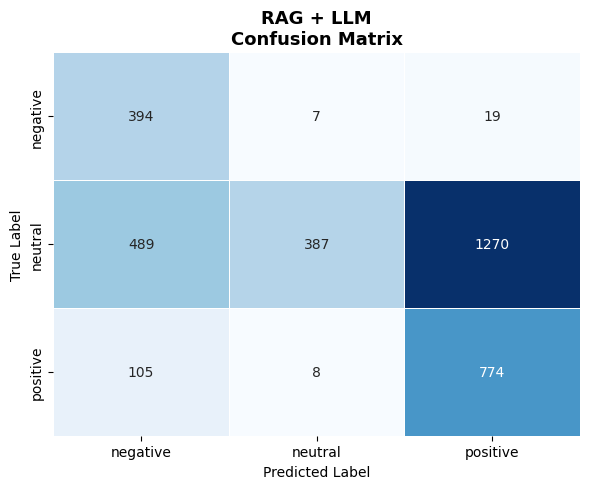

In [25]:
# ============================================================
# 3C.4  RAG EVALUATION
# ============================================================
results_rag = evaluate_model(df['label'], df['rag_pred'], 'RAG + LLM')

Evaluating RAG with different k values...
  k= 3  →  Accuracy=45.03%
  k= 5  →  Accuracy=45.03%
  k=10  →  Accuracy=45.03%


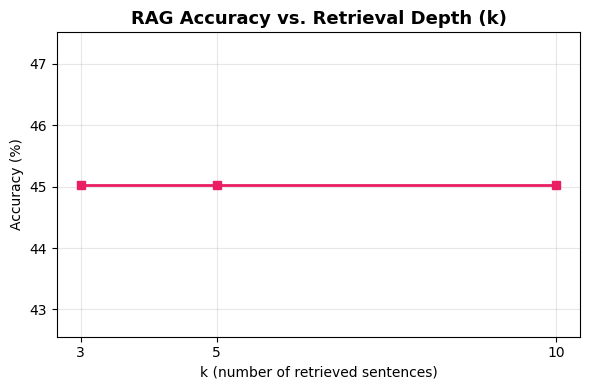

In [26]:
# Experiment: Different K values
print('Evaluating RAG with different k values...')
k_results = {}
for k in [3, 5, 10]:
    preds_k = []
    for i in range(len(sentences_list)):
        idx_list, _ = retrieve_context(embeddings[i], k)
        context_str = ' | '.join([sentences_list[j] for j in idx_list[:3]])
        aug = f"{sentences_list[i]} [Context: {context_str}]"
        r = zs_pipeline(aug, candidate_labels=CANDIDATE_LABELS,
                         multi_label=False, truncation=True)
        preds_k.append(LABEL_MAPPING[r['labels'][0]])
    k_acc = accuracy_score(df['label'], preds_k)
    k_results[k] = k_acc
    print(f'  k={k:2d}  →  Accuracy={k_acc*100:.2f}%')

# Plot k sensitivity
plt.figure(figsize=(6, 4))
plt.plot(list(k_results.keys()), [v*100 for v in k_results.values()],
         marker='s', color='#E91E63', linewidth=2)
plt.title('RAG Accuracy vs. Retrieval Depth (k)', fontsize=13, fontweight='bold')
plt.xlabel('k (number of retrieved sentences)')
plt.ylabel('Accuracy (%)')
plt.xticks([3, 5, 10])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rag_k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Comparative Analysis

In [27]:
# ============================================================
# 4.1  METRIC COMPARISON TABLE
# ============================================================
all_results = [results_finbert, results_llm, results_rag]
comparison_df = pd.DataFrame([
    {
        'Model': r['model'],
        'Accuracy (%)': round(r['accuracy']*100, 2),
        'Precision (%)': round(r['precision']*100, 2),
        'Recall (%)': round(r['recall']*100, 2),
        'F1-Score (%)': round(r['f1']*100, 2)
    } for r in all_results
])

print('\n=== COMPARATIVE METRICS TABLE ===')
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv('results_comparison.csv', index=False)
df.to_csv('full_predictions.csv', index=False)
print('\nResults saved to results_comparison.csv')


=== COMPARATIVE METRICS TABLE ===
                Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
              FinBERT         94.73          95.14       94.73         94.80
Local LLM (Zero-Shot)         52.39          77.37       52.39         48.46
            RAG + LLM         45.03          74.32       45.03         39.17

Results saved to results_comparison.csv


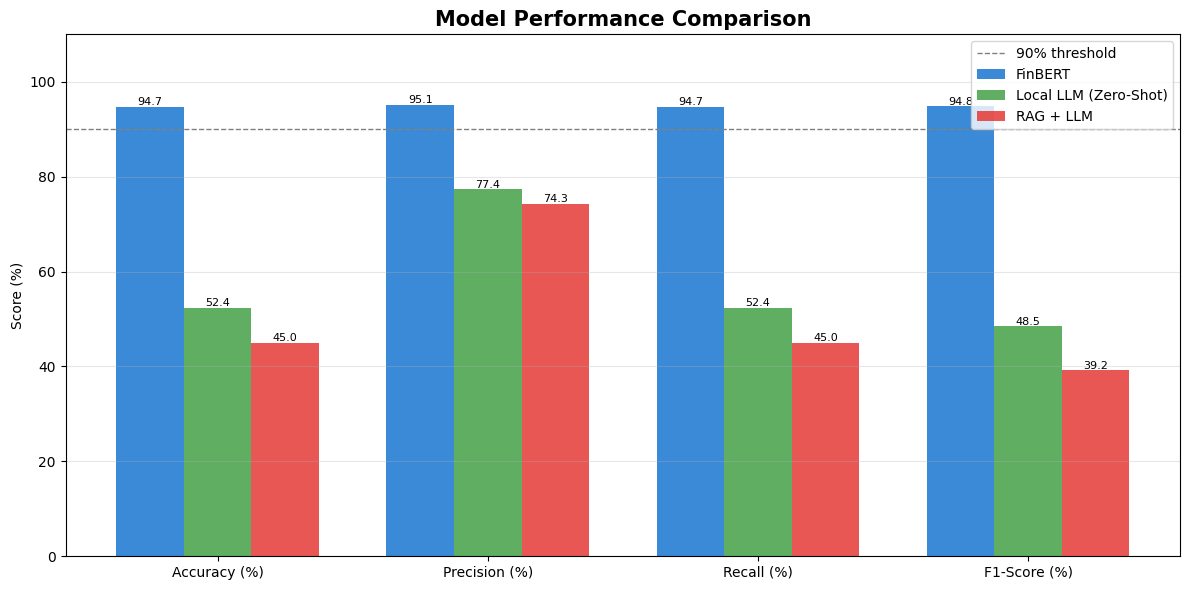

In [28]:
# ============================================================
# 4.2  VISUALIZATION – Side-by-side Metrics
# ============================================================
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
models  = comparison_df['Model'].tolist()

x = np.arange(len(metrics))
width = 0.25
colors = ['#1976D2', '#43A047', '#E53935']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = comparison_df[comparison_df['Model'] == model][metrics].values.flatten()
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)

ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.axhline(90, color='gray', linestyle='--', linewidth=1, label='90% threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ============================================================
# 4.3  ERROR ANALYSIS
# ============================================================
print('=== Error Analysis ===')

# Common mistakes for each model
for col, name in [('finbert_pred', 'FinBERT'),
                   ('llm_pred', 'LLM'),
                   ('rag_pred', 'RAG')]:
    errors = df[df[col] != df['label']]
    print(f'\n{name}: {len(errors)} errors')
    err_pairs = [(t, p) for t, p in zip(errors['label'], errors[col])]
    print('  Most common error pairs (true→pred):',
          Counter(err_pairs).most_common(5))

# Show hard examples (all 3 models wrong)
all_wrong = df[~df['finbert_correct'] & ~df['llm_correct'] & ~df['rag_correct']]
print(f'\n--- Sentences ALL models got wrong ({len(all_wrong)} total) ---')
for _, row in all_wrong.head(5).iterrows():
    print(f'  Sentence  : {row["sentence"][:90]}')
    print(f'  True label: {row["label"]}  |  FinBERT: {row["finbert_pred"]}  '
          f'LLM: {row["llm_pred"]}  RAG: {row["rag_pred"]}')
    print()

=== Error Analysis ===

FinBERT: 182 errors
  Most common error pairs (true→pred): [(('neutral', 'positive'), 93), (('neutral', 'negative'), 52), (('positive', 'negative'), 15), (('positive', 'neutral'), 15), (('negative', 'positive'), 5)]

LLM: 1644 errors
  Most common error pairs (true→pred): [(('neutral', 'positive'), 1332), (('neutral', 'negative'), 257), (('positive', 'negative'), 31), (('negative', 'neutral'), 12), (('negative', 'positive'), 7)]

RAG: 1898 errors
  Most common error pairs (true→pred): [(('neutral', 'positive'), 1270), (('neutral', 'negative'), 489), (('positive', 'negative'), 105), (('negative', 'positive'), 19), (('positive', 'neutral'), 8)]

--- Sentences ALL models got wrong (127 total) ---
  Sentence  : In Sweden , Gallerix accumulated SEK denominated sales were down 1 % and EUR denominated s
  True label: neutral  |  FinBERT: negative  LLM: negative  RAG: negative

  Sentence  : STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WI

---
## 5. Fine-Tuning Decision & Implementation

In [30]:
# ============================================================
# 5.1  FINE-TUNING DECISION
# ============================================================
THRESHOLD = 0.90
best_acc = max(r['accuracy'] for r in all_results)
best_model_name = max(all_results, key=lambda r: r['accuracy'])['model']

print('=== Fine-Tuning Decision ===')
print(f'Best accuracy so far: {best_acc*100:.2f}% ({best_model_name})')

if best_acc >= THRESHOLD:
    FINE_TUNE_REQUIRED = False
    print(f'✅ Accuracy ≥ 90% achieved. Fine-tuning is NOT required.')
else:
    FINE_TUNE_REQUIRED = True
    print(f'⚠️  No model achieved 90%. Fine-tuning IS required.')

print(f'FINE_TUNE_REQUIRED = {FINE_TUNE_REQUIRED}')

=== Fine-Tuning Decision ===
Best accuracy so far: 94.73% (FinBERT)
✅ Accuracy ≥ 90% achieved. Fine-tuning is NOT required.
FINE_TUNE_REQUIRED = False


---
## 6. Final Comprehensive Summary

In [36]:
# ============================================================
# 6.1  FINAL COMPARISON TABLE (including fine-tuned)
# ============================================================



all_final = [results_finbert, results_llm, results_rag]
final_df = pd.DataFrame([
    {
        'Model': r['model'],
        'Accuracy (%)':  round(r['accuracy']*100, 2),
        'Precision (%)': round(r['precision']*100, 2),
        'Recall (%)':    round(r['recall']*100, 2),
        'F1-Score (%)':  round(r['f1']*100, 2)
    } for r in all_final
])
print('\n=== FINAL RESULTS TABLE ===')
print(final_df.to_string(index=False))
final_df.to_csv('final_results.csv', index=False)


=== FINAL RESULTS TABLE ===
                Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
              FinBERT         94.73          95.14       94.73         94.80
Local LLM (Zero-Shot)         52.39          77.37       52.39         48.46
            RAG + LLM         45.03          74.32       45.03         39.17


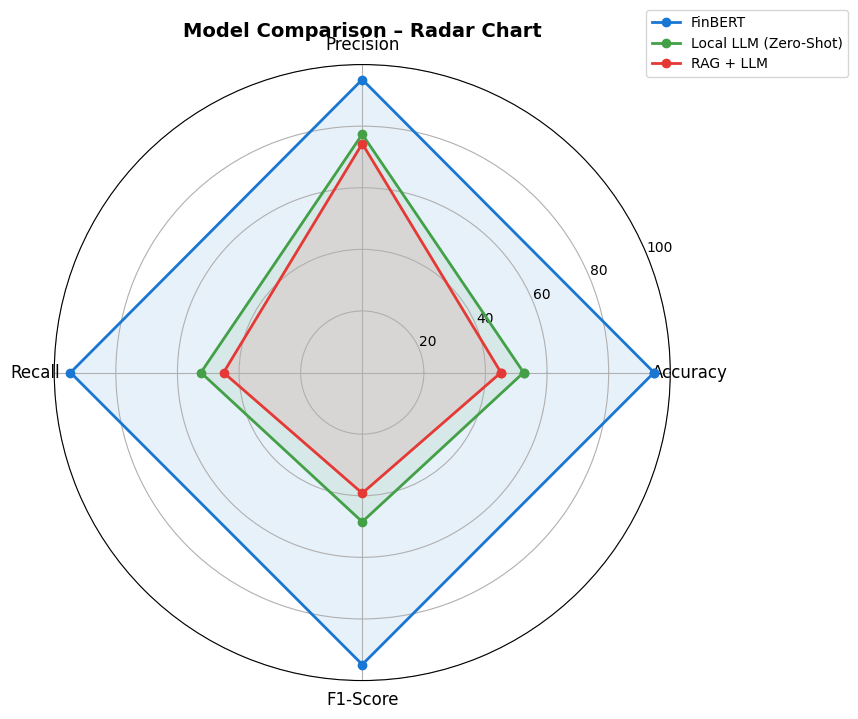

In [37]:
# ============================================================
# 6.2  RADAR CHART – Final Model Comparison
# ============================================================
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#1976D2', '#43A047', '#E53935', '#FF9800']

for r, color in zip(all_final, colors_radar):
    vals = [r['accuracy']*100, r['precision']*100,
             r['recall']*100, r['f1']*100]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=r['model'])
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Model Comparison – Radar Chart', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ============================================================
# 6.4  FINAL SUMMARY PRINT
# ============================================================
print('='*60)
print(' CS4045 Assignment #3 – Final Summary')
print(' Student: Ayoob Haroon | 20I-0777 | CS-A')
print('='*60)
print()
print('Dataset: Financial PhraseBank (75% agreement)')
print(f'  Total samples: {len(df)}')
print(f'  Classes: {dict(df["label"].value_counts())}')
print()
print(f'LDA Topic Modeling:')
print(f'  Optimal topics: {NUM_TOPICS}')
print(f'  Final coherence (c_v): {cm_final.get_coherence():.4f}')
print()
print('Sentiment Analysis Results:')
for r in all_final:
    print(f'  {r["model"]:<35s}  Acc={r["accuracy"]*100:.2f}%  F1={r["f1"]*100:.2f}%')
print()
print(f'Fine-Tuning Required: {FINE_TUNE_REQUIRED}')

print('='*60)

 CS4045 Assignment #3 – Final Summary
 Student: Ayoob Haroon | 20I-0777 | CS-A

Dataset: Financial PhraseBank (75% agreement)
  Total samples: 3453
  Classes: {'neutral': np.int64(2146), 'positive': np.int64(887), 'negative': np.int64(420)}

LDA Topic Modeling:
  Optimal topics: 13
  Final coherence (c_v): 0.4041

Sentiment Analysis Results:
  FinBERT                              Acc=94.73%  F1=94.80%
  Local LLM (Zero-Shot)                Acc=52.39%  F1=48.46%
  RAG + LLM                            Acc=45.03%  F1=39.17%

Fine-Tuning Required: False
